# Qwen2.5-1.5B DeepReasoning ablation

This is the presentation notebook. It shows the training/evaluation code, recomputes metrics and charts from saved artifacts, and runs a tiny live adapter inference demo when CUDA is available.

In [1]:

from pathlib import Path
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ART = Path('artifacts_qwen15b')
RUNS = [
    'qwen15_len1024_r8_a16_lr5e5_e3_es',
    'qwen15_len1024_r8_a16_lr2e5_e3_es',
    'qwen15_len1024_r16_a32_lr5e5_e3_es',
]
LEADER_RUN = 'qwen15_len1024_r8_a16_lr5e5_e3_es'
CONFIRM_DIR = ART / 'confirm_qwen15_len1024_r8_a16_lr5e5_e3_es_greedy100'

def load_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

def load_jsonl(path):
    path = Path(path)
    return [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]

def extract_tag(text, tag):
    match = re.search(fr'<{tag}>(.*?)</{tag}>', text, re.DOTALL | re.IGNORECASE)
    return match.group(1).strip() if match else ''

def normalize_number(text):
    numbers = re.findall(r'-?\d+(?:\.\d+)?', str(text).replace(',', '').replace('$', ''))
    if not numbers:
        return ''
    value = float(numbers[-1])
    return str(int(value)) if value.is_integer() else str(value)

def score_trace(trace, gold):
    thinking = extract_tag(trace, 'thinking')
    reflection = extract_tag(trace, 'reflection')
    answer = extract_tag(trace, 'answer')
    strict_prediction = normalize_number(answer)
    loose_prediction = strict_prediction or normalize_number(trace)
    return {
        'strict_prediction': strict_prediction,
        'loose_prediction': loose_prediction,
        'valid_format': bool(thinking and reflection and answer),
        'has_reflection': bool(reflection),
        'strict_correct': strict_prediction == gold,
        'loose_correct': loose_prediction == gold,
    }

confirm_summary = load_json(CONFIRM_DIR / 'evaluation_summary.json')
print('Loaded artifact root:', ART)
print('Runs:', len(RUNS))
print('100-question confirmation examples:', confirm_summary['n_examples'])


Loaded artifact root: artifacts_qwen15b
Runs: 3
100-question confirmation examples: 100


## 1. Research question and conclusion

In [2]:
display(Markdown((ART / 'QWEN15B_PRESENTATION_REPORT.md').read_text()))

# Qwen2.5-1.5B DeepReasoning ablation report

## One-slide conclusion

We repeated the QLoRA DeepReasoning pipeline with `Qwen/Qwen2.5-1.5B-Instruct` because the 3B model was less stressed by the dataset. The best adapter was `qwen15_len1024_r8_a16_lr5e5_e3_es`.

| Metric | Base | Adapter | Interpretation |
|---|---:|---:|---|
| Strict tagged answer, 100 questions | 0.0% | 48.0% | Adapter wins because the required format matters. |
| Loose numeric answer, 100 questions | 55.0% | 49.0% | Base remains slightly better at raw math answers. |
| Valid required format | 0.0% | 75.0% | LoRA mainly teaches format/instruction following. |

## Why this pipeline

- Same fixed training split and GSM8K evaluation indices across runs.
- Separate `artifacts_qwen15b` root so no cached 3B base generations contaminate 1.5B results.
- 30-question greedy screens for quick hyperparameter comparison.
- 100-question no-retraining confirmation only for the best screened adapter.
- Strict and loose metrics are both reported because format compliance and final-answer accuracy answer different questions.

## Runtime decisions

- Batch 32 / grad accum 1 OOMed near full VRAM.
- Batch 16 / grad accum 2 also OOMed during the fp32 full-vocabulary loss.
- Batch 8 / grad accum 4 was stable and kept the same effective batch size of 32.
- All stable runs used 3 epochs with early stopping enabled. In practice, validation loss kept improving, so all three ran the full 3 epochs.

## 30-question screen

| run                                |   rank |   alpha |     lr |   epochs |   train_batch |   grad_accum |   effective_batch |   trainable_params_m |   truncation_rate |   eval_loss |   best_eval_loss |   train_minutes |   max_gpu_gib |   strict_accuracy_30 |   loose_accuracy_30 |   format_rate_30 |   reflection_rate_30 |   mean_latency_s_30 |
|:-----------------------------------|-------:|--------:|-------:|---------:|--------------:|-------------:|------------------:|---------------------:|------------------:|------------:|-----------------:|----------------:|--------------:|---------------------:|--------------------:|-----------------:|---------------------:|--------------------:|
| qwen15_len1024_r8_a16_lr5e5_e3_es  |      8 |      16 | 0.0001 |   3.0000 |             8 |            4 |                32 |               9.2324 |            0.1500 |      0.4018 |           0.4018 |          9.2226 |       56.2719 |               0.6333 |              0.6333 |           0.9000 |               0.9000 |             15.3797 |
| qwen15_len1024_r8_a16_lr2e5_e3_es  |      8 |      16 | 0.0000 |   3.0000 |             8 |            4 |                32 |               9.2324 |            0.1500 |      0.4558 |           0.4558 |          9.2346 |       56.2719 |               0.5667 |              0.6333 |           0.8000 |               0.8000 |             17.3790 |
| qwen15_len1024_r16_a32_lr5e5_e3_es |     16 |      32 | 0.0001 |   3.0000 |             8 |            4 |                32 |              18.4648 |            0.1500 |      0.3832 |           0.3832 |          9.2382 |       56.3761 |               0.5333 |              0.5667 |           0.8000 |               0.8333 |             16.4729 |

The screen selected `qwen15_len1024_r8_a16_lr5e5_e3_es` because it had the best strict accuracy (63.3%) and best format rate (90.0%). The r=16 run had lower validation loss but worse answer accuracy, which is why we did not rely on validation loss alone.

## Final interpretation

The best defensible configuration is `qwen15_len1024_r8_a16_lr5e5_e3_es` if the assignment rewards structured reasoning traces. If the only objective is raw GSM8K numeric accuracy, the base 1.5B model is still slightly better. The experiment therefore demonstrates a format-following gain with a raw-answer tradeoff.


## 2. Training configuration

This is the actual configuration family. Full training is disabled here so the notebook remains safe to present.

In [3]:

# This cell documents the actual training configuration.
# It is safe during presentation because RUN_FULL_TRAINING is False.
RUN_FULL_TRAINING = False

if RUN_FULL_TRAINING:
    MODEL_ID = 'Qwen/Qwen2.5-1.5B-Instruct'
    DATA_PATH = 'data/sft_reasoning_2k.jsonl'
    ARTIFACT_ROOT = 'artifacts_qwen15b'

    MAX_LEN = 1024
    LORA_R = 8
    LORA_ALPHA = 16
    LEARNING_RATE = 5e-5
    NUM_EPOCHS = 3

    # Batch 32 and batch 16 OOMed; batch 8 kept memory stable.
    TRAIN_BATCH_SIZE = 8
    GRADIENT_ACCUMULATION_STEPS = 4
    EFFECTIVE_BATCH_SIZE = TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS
    EVAL_BATCH_SIZE = 8
    GRADIENT_CHECKPOINTING = False

    EVAL_STEPS = 20
    SAVE_STEPS = 20
    EARLY_STOPPING_PATIENCE = 3
    EARLY_STOPPING_THRESHOLD = 5e-4
    MAX_NEW_TOKENS = 768


## 3. Core QLoRA training code

In [4]:

# Core QLoRA training code used by the experiment.
# This mirrors the cloud run but is guarded to avoid accidental retraining.
if RUN_FULL_TRAINING:
    import torch
    from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
    from transformers import (
        AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig,
        DataCollatorForSeq2Seq, EarlyStoppingCallback,
        Trainer, TrainingArguments,
    )

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    quantization = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=quantization,
        device_map={'': 0},
        torch_dtype=torch.bfloat16,
    )
    model = prepare_model_for_kbit_training(model)

    lora_config = LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=0.05,
        bias='none',
        task_type='CAUSAL_LM',
        target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj',
                        'gate_proj', 'up_proj', 'down_proj'],
    )
    model = get_peft_model(model, lora_config)

    args = TrainingArguments(
        output_dir=f'{ARTIFACT_ROOT}/{RUN_NAME}/checkpoints',
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        num_train_epochs=NUM_EPOCHS,
        learning_rate=LEARNING_RATE,
        lr_scheduler_type='cosine',
        warmup_ratio=0.03,
        optim='paged_adamw_8bit',
        bf16=True,
        tf32=True,
        gradient_checkpointing=GRADIENT_CHECKPOINTING,
        logging_steps=1,
        eval_strategy='steps',
        eval_steps=EVAL_STEPS,
        save_strategy='steps',
        save_steps=SAVE_STEPS,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        greater_is_better=False,
        report_to=[],
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tokenized,
        eval_dataset=eval_tokenized,
        data_collator=DataCollatorForSeq2Seq(
            tokenizer=tokenizer,
            padding=True,
            label_pad_token_id=-100,
            pad_to_multiple_of=8,
        ),
        processing_class=tokenizer,
        callbacks=[EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            early_stopping_threshold=EARLY_STOPPING_THRESHOLD,
        )],
    )
    trainer.train()
    trainer.evaluate()
    trainer.save_model(adapter_dir)
    tokenizer.save_pretrained(adapter_dir)


## 4. Evaluation/scoring code

In [5]:

# Evaluation/scoring code used in the screen and confirmation.
# Strict accuracy requires the final answer inside <answer>; loose accuracy
# extracts the last number from the whole trace even if tags are missing.
SYSTEM_INSTRUCTION = '''You are a meticulous reasoning tutor.
For every problem, answer using EXACTLY these tags in order:
<thinking>
Reason step by step. Show every intermediate calculation.
</thinking>
<reflection>
Re-check your reasoning. Look for arithmetic slips or wrong assumptions.
</reflection>
<answer>
Give only the final answer.
</answer>'''

print(score_trace('<thinking>x</thinking><reflection>ok</reflection><answer>42</answer>', '42'))


{'strict_prediction': '42', 'loose_prediction': '42', 'valid_format': True, 'has_reflection': True, 'strict_correct': True, 'loose_correct': True}


## 5. Recompute the 30-question screen from raw predictions

In [6]:

# Recompute the screen table from raw artifacts and raw prediction JSONLs.
# This is not just displaying a pre-made image: we parse predictions again here.
rows = []
for run in RUNS:
    run_dir = ART / run
    cfg = load_json(run_dir / 'config.json')
    train = load_json(run_dir / 'training_summary.json')
    params = load_json(run_dir / 'parameter_stats.json')
    tokens = load_json(run_dir / 'tokenization_stats.json')
    predictions = load_jsonl(run_dir / 'raw' / 'adapter_predictions.jsonl')

    strict_scores = []
    loose_scores = []
    format_scores = []
    for row in predictions:
        trace = row.get('greedy_trace', row.get('trace', ''))
        scored = score_trace(trace, row['gold_answer'])
        strict_scores.append(scored['strict_correct'])
        loose_scores.append(scored['loose_correct'])
        format_scores.append(scored['valid_format'])

    rows.append({
        'run': run,
        'rank': cfg['lora_r'],
        'alpha': cfg['lora_alpha'],
        'lr': cfg['learning_rate'],
        'train_batch': cfg['train_batch_size'],
        'grad_accum': cfg['gradient_accumulation_steps'],
        'effective_batch': cfg['train_batch_size'] * cfg['gradient_accumulation_steps'],
        'trainable_params_m': params['trainable_parameters'] / 1e6,
        'truncation_rate': tokens['train']['truncated_fraction'],
        'eval_loss': train['eval_loss'],
        'train_minutes': train['train_wall_time_seconds'] / 60,
        'max_gpu_gib': train['max_gpu_memory_allocated_gib'],
        'strict_accuracy_30': np.mean(strict_scores),
        'loose_accuracy_30': np.mean(loose_scores),
        'format_rate_30': np.mean(format_scores),
    })

screen_df = pd.DataFrame(rows).sort_values('strict_accuracy_30', ascending=False)
display(screen_df)
leader = screen_df.iloc[0]
print('Selected leader:', leader['run'])


,run,rank,alpha,lr,train_batch,grad_accum,effective_batch,trainable_params_m,truncation_rate,eval_loss,train_minutes,max_gpu_gib,strict_accuracy_30,loose_accuracy_30,format_rate_30
0,qwen15_len1024_r8_a16_lr5e5_e3_es,8,16,0.00005,8,4,32,9.232384,0.15,0.401758,9.222645,56.271918,0.633333,0.633333,0.9
1,qwen15_len1024_r8_a16_lr2e5_e3_es,8,16,0.00002,8,4,32,9.232384,0.15,0.455819,9.234625,56.271918,0.566667,0.633333,0.8
2,qwen15_len1024_r16_a32_lr5e5_e3_es,16,32,0.00005,8,4,32,18.464768,0.15,0.383190,9.238208,56.376098,0.533333,0.566667,0.8


Selected leader: qwen15_len1024_r8_a16_lr5e5_e3_es


## 6. Generate screen charts from recomputed data

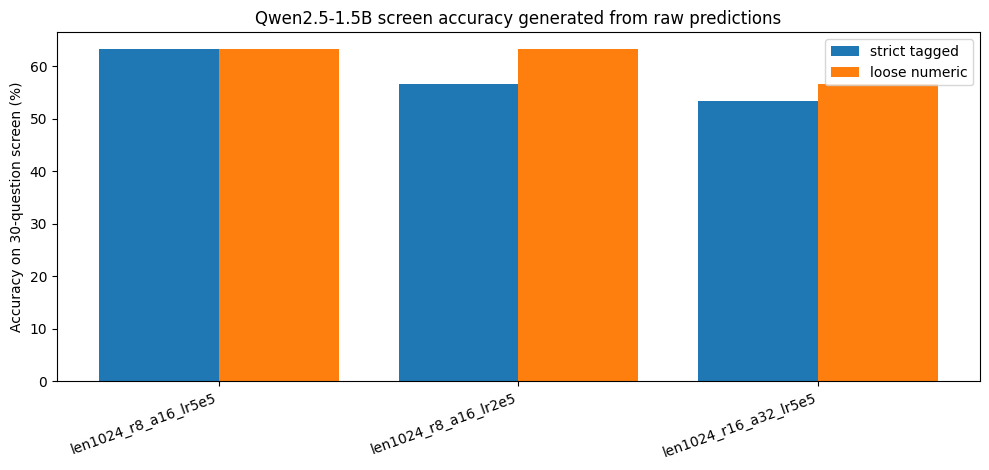

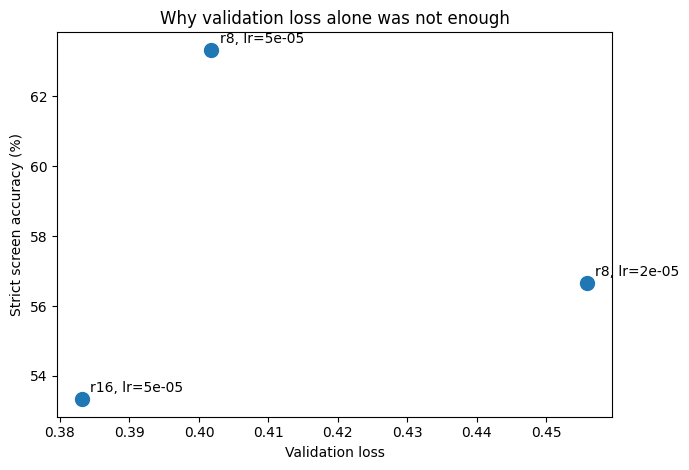

In [7]:

# Generate charts live from screen_df.
labels = [name.replace('qwen15_', '').replace('_e3_es', '') for name in screen_df['run']]
x = np.arange(len(screen_df))

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(x - 0.2, 100 * screen_df['strict_accuracy_30'], width=0.4, label='strict tagged')
ax.bar(x + 0.2, 100 * screen_df['loose_accuracy_30'], width=0.4, label='loose numeric')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('Accuracy on 30-question screen (%)')
ax.set_title('Qwen2.5-1.5B screen accuracy generated from raw predictions')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.scatter(screen_df['eval_loss'], 100 * screen_df['strict_accuracy_30'], s=100)
for _, row in screen_df.iterrows():
    ax.annotate(f"r{int(row['rank'])}, lr={row['lr']:.0e}",
                (row['eval_loss'], 100 * row['strict_accuracy_30']),
                xytext=(6, 5), textcoords='offset points')
ax.set_xlabel('Validation loss')
ax.set_ylabel('Strict screen accuracy (%)')
ax.set_title('Why validation loss alone was not enough')
plt.tight_layout()
plt.show()


## 7. Training curves and OOM/runtime evidence

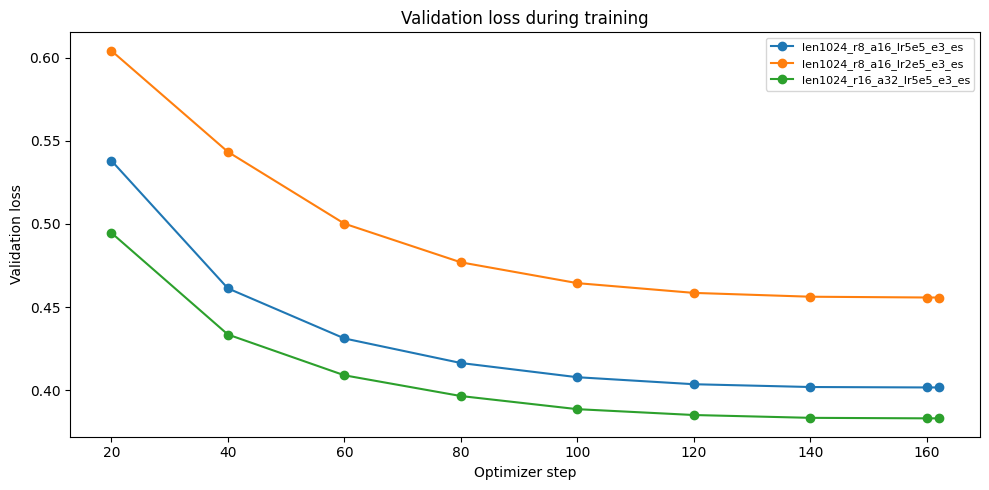

OOM evidence from failed speed attempts:

--- oom_qwen15_len1024_r8_a16_lr5e5_e3_es_bs16 ---
# OOM record

Batch 16 / grad accum 2 still OOMed during fp32 loss over full vocab logits. Relaunch uses batch 8 / grad accum 4.

2026-07-07T20:41:51.115357Z


--- oom_qwen15_len1024_r8_a16_lr5e5_e3_es_bs32 ---
# OOM / interrupted batch-32 attempt

Batch 32 / grad accum 1 was not VRAM safe. Relaunch uses batch 16 / grad accum 2.

2026-07-07T20:40:32.358790Z



In [8]:

# Generate validation curves live from Trainer log history.
fig, ax = plt.subplots(figsize=(10, 5))
for run in RUNS:
    history = pd.read_json(ART / run / 'raw' / 'trainer_log_history.json')
    eval_history = history.dropna(subset=['eval_loss'])
    ax.plot(eval_history['step'], eval_history['eval_loss'], marker='o', label=run.replace('qwen15_', ''))
ax.set_xlabel('Optimizer step')
ax.set_ylabel('Validation loss')
ax.set_title('Validation loss during training')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('OOM evidence from failed speed attempts:')
for oom_dir in sorted(ART.glob('oom_*')):
    record = oom_dir / 'OOM_RECORD.md'
    if record.exists():
        print(f'\n--- {oom_dir.name} ---')
        print(record.read_text())


## 8. Recompute 100-question confirmation from raw predictions

In [9]:

# Recompute the 100-question confirmation from raw base/adapter prediction JSONLs.
base_records = load_jsonl(CONFIRM_DIR / 'base_predictions.jsonl')
adapter_records = load_jsonl(CONFIRM_DIR / 'adapter_predictions.jsonl')

summary_rows = []
for mode, records in [('base', base_records), ('adapter', adapter_records)]:
    strict = []
    loose = []
    fmt = []
    reflection = []
    for row in records:
        scored = score_trace(row['trace'], row['gold_answer'])
        strict.append(scored['strict_correct'])
        loose.append(scored['loose_correct'])
        fmt.append(scored['valid_format'])
        reflection.append(scored['has_reflection'])
    summary_rows.append({
        'mode': mode,
        'strict_accuracy': np.mean(strict),
        'loose_accuracy': np.mean(loose),
        'valid_format_rate': np.mean(fmt),
        'reflection_rate': np.mean(reflection),
        'n': len(records),
    })
confirm_df = pd.DataFrame(summary_rows)
display(confirm_df)
print('Raw rows:', len(base_records), 'base and', len(adapter_records), 'adapter')


,mode,strict_accuracy,loose_accuracy,valid_format_rate,reflection_rate,n
0,base,0.00,0.55,0.00,0.00,100
1,adapter,0.48,0.49,0.75,0.75,100


Raw rows: 100 base and 100 adapter


## 9. Generate confirmation charts from recomputed data

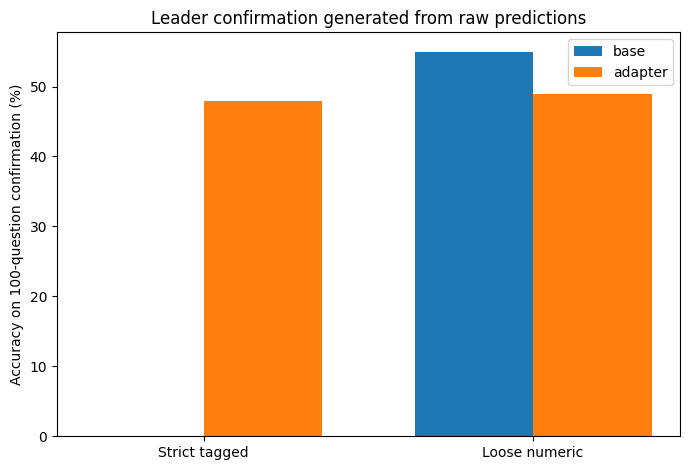

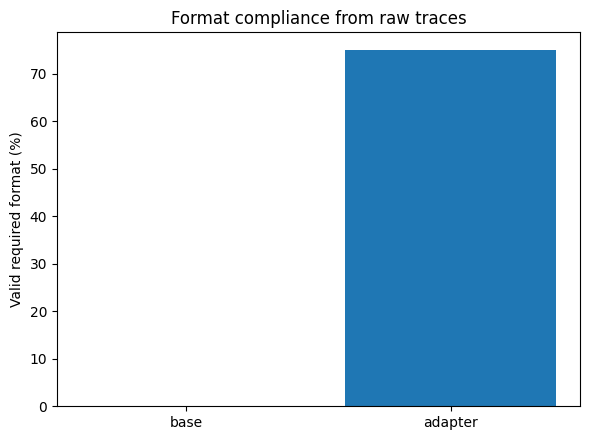

In [10]:

# Generate confirmation charts live from confirm_df.
fig, ax = plt.subplots(figsize=(7, 4.8))
x = np.arange(2)
base = confirm_df[confirm_df['mode'] == 'base'].iloc[0]
adapter = confirm_df[confirm_df['mode'] == 'adapter'].iloc[0]
ax.bar(x - 0.18, [100 * base['strict_accuracy'], 100 * base['loose_accuracy']], width=0.36, label='base')
ax.bar(x + 0.18, [100 * adapter['strict_accuracy'], 100 * adapter['loose_accuracy']], width=0.36, label='adapter')
ax.set_xticks(x)
ax.set_xticklabels(['Strict tagged', 'Loose numeric'])
ax.set_ylabel('Accuracy on 100-question confirmation (%)')
ax.set_title('Leader confirmation generated from raw predictions')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(['base', 'adapter'], [100 * base['valid_format_rate'], 100 * adapter['valid_format_rate']])
ax.set_ylabel('Valid required format (%)')
ax.set_title('Format compliance from raw traces')
plt.tight_layout()
plt.show()


## 10. Tiny live inference demo with the saved adapter

In [11]:

# Tiny live inference demo with the saved adapter.
# This runs on the cloud GPU when CUDA is available; otherwise it falls back gracefully.
RUN_LIVE_INFERENCE = True

if RUN_LIVE_INFERENCE:
    try:
        import torch
        if not torch.cuda.is_available():
            print('CUDA is not available, so live inference is skipped in this environment.')
        else:
            from datasets import load_dataset
            from peft import PeftModel
            from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

            MODEL_ID = 'Qwen/Qwen2.5-1.5B-Instruct'
            ADAPTER_DIR = ART / LEADER_RUN / 'adapter'
            indices = load_json(CONFIRM_DIR / 'gsm8k_test_indices.json')
            example_index = indices[0]
            example = load_dataset('openai/gsm8k', 'main', split='test').select([example_index])[0]
            gold = normalize_number(example['answer'].split('####')[-1])

            tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR)
            if tokenizer.pad_token_id is None:
                tokenizer.pad_token = tokenizer.eos_token

            quantization = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type='nf4',
                bnb_4bit_use_double_quant=True,
                bnb_4bit_compute_dtype=torch.bfloat16,
            )
            base_model = AutoModelForCausalLM.from_pretrained(
                MODEL_ID,
                quantization_config=quantization,
                device_map={'': 0},
                torch_dtype=torch.bfloat16,
            )
            model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
            model.eval()

            messages = [
                {'role': 'system', 'content': SYSTEM_INSTRUCTION},
                {'role': 'user', 'content': example['question']},
            ]
            encoded = tokenizer.apply_chat_template(
                messages,
                add_generation_prompt=True,
                return_tensors='pt',
                return_dict=True,
            ).to(model.device)

            with torch.inference_mode():
                output = model.generate(
                    **encoded,
                    do_sample=False,
                    max_new_tokens=768,
                    pad_token_id=tokenizer.pad_token_id,
                    eos_token_id=tokenizer.eos_token_id,
                )
            trace = tokenizer.decode(output[0, encoded['input_ids'].shape[1]:], skip_special_tokens=True)
            scored = score_trace(trace, gold)

            print('Question:')
            print(example['question'])
            print('\nGold answer:', gold)
            print('\nGenerated adapter trace:')
            print(trace)
            print('\nParsed score:')
            print(json.dumps(scored, indent=2))

            del model, base_model
            torch.cuda.empty_cache()
    except Exception as exc:
        print('Live inference skipped because this environment could not run it:')
        print(type(exc).__name__, exc)


`torch_dtype` is deprecated! Use `dtype` instead!


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Question:
Melanie is a door-to-door saleswoman. She sold a third of her vacuum cleaners at the green house, 2 more to the red house, and half of what was left at the orange house. If Melanie has 5 vacuum cleaners left, how many did she start with?

Gold answer: 18

Generated adapter trace:
<thinking>
Let M be the total number of vacuum cleaners Melanie started with.

Step 1: Calculate the number of vacuum cleaners sold at the green house.
She sold a third of them.
Number sold at green = (1/3) * M

Step 2: Calculate the remaining vacuum cleaners after selling at the green house.
Remaining after green = M - (1/3)M = (2/3)M

Step 3: Add the number of vacuum cleaners sold at the red house.
She sold 2 more to the red house.
Total sold so far = (1/3)M + 2

Step 4: Calculate the remaining vacuum cleaners after selling at the red house.
Remaining after red = (2/3)M - ((1/3)M + 2)

Step 5: Calculate the number of vacuum cleaners sold at the orange house.
She sold half of what was left at the or

## 11. Final takeaway

The adapter is best when structured reasoning format is required. The base model remains slightly better on loose final numeric answer accuracy. This is the core tradeoff shown by the ablation.